# Level 2 – Engineering Operations in Signal Processing

# Level 2.1 – Filtering

Filtering is the process of modifying a signal by allowing certain frequency components to pass while reducing or removing others.  
The main purpose of filtering is to improve signal quality, remove unwanted noise, isolate useful information, or prepare the signal for further processing.

### Why Do We Need Filtering?
* Remove background noise from speech
* Remove electrical interference (50/60 Hz hum)
* Smooth sensor measurements
* Separate bass and treble in audio
* Remove high-frequency camera noise

---

## Mathematical Equation
A general finite impulse response (FIR) discrete-time filter is defined as:

$$y[n] = \sum_{k=0}^{M} b_k x[n-k]$$

Where:
* $b_k$ are the filter coefficients
* $M$ is the filter order

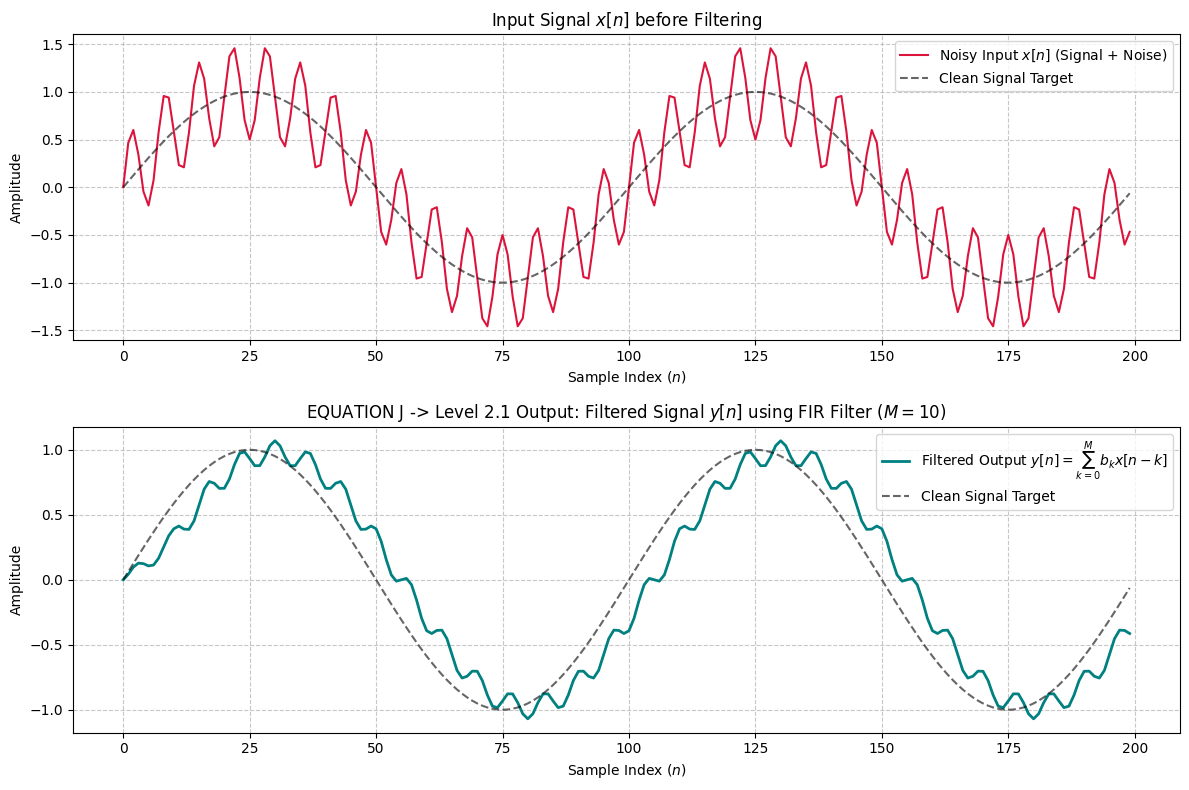

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Input Signal: x[n] = Clean Signal + High-Frequency Noise
# ------------------------------------------------------------------------------
fs = 1000                          # Sampling rate (Hz)
N = 200                            # Total number of discrete samples
n = np.arange(N)                   # Discrete sample indices [0, 1, 2, ..., N-1]
t = n / fs                         # Time vector (seconds)

# Low-frequency clean audio/sensor signal (10 Hz sine wave)
x_clean = np.sin(2 * np.pi * 10 * t)

# High-frequency noise (150 Hz interference)
noise = 0.5 * np.sin(2 * np.pi * 150 * t)

# Corrupted input signal x[n]
x = x_clean + noise

# ------------------------------------------------------------------------------
# 2. Implement Equation J: Discrete-Time FIR Filtering
#    Equation J: y[n] = \sum_{k=0}^{M} b_k * x[n-k]
# ------------------------------------------------------------------------------
M = 10                             # Filter Order (number of delays)
b_k = np.ones(M + 1) / (M + 1)     # Moving average coefficients (b_k = 1 / (M + 1))

# Initialize output array y[n] with zeros
y = np.zeros(N)

# Direct implementation of Equation J using discrete summation loop
for n_idx in range(N):
    accumulator = 0.0
    for k in range(M + 1):
        if (n_idx - k) >= 0:      # Ensure causality (x[n-k] exists for n-k >= 0)
            accumulator += b_k[k] * x[n_idx - k]
    y[n_idx] = accumulator

# ------------------------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Subplot 1: Corrupted Input Signal x[n]
plt.subplot(2, 1, 1)
plt.plot(n, x, color='crimson', label=r'Noisy Input $x[n]$ (Signal + Noise)')
plt.plot(n, x_clean, 'k--', alpha=0.6, label=r'Clean Signal Target')
plt.title(r'Input Signal $x[n]$ before Filtering')
plt.xlabel('Sample Index ($n$)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: Filtered Output Signal y[n] via Equation J
plt.subplot(2, 1, 2)
plt.plot(n, y, color='teal', linewidth=2, 
         label=r'Filtered Output $y[n] = \sum_{k=0}^{M} b_k x[n-k]$')
plt.plot(n, x_clean, 'k--', alpha=0.6, label=r'Clean Signal Target')
plt.title(r'EQUATION J -> Level 2.1 Output: Filtered Signal $y[n]$ using FIR Filter ($M=10$)')
plt.xlabel('Sample Index ($n$)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.2 – Amplification

Amplification increases the amplitude of a signal while preserving its waveform and frequency content.  
It is used when the signal is too weak for processing or playback.

### Why Do We Need Amplification?
* Increase microphone signals
* Boost sensor outputs
* Increase speaker volume

---

## Mathematical Equation
An ideal discrete-time amplifier is defined as:

$$y[n] = G \cdot x[n]$$

Where:
* $G > 1$ is the gain coefficient
* $x[n]$ is the original input signal
* $y[n]$ is the amplified output signal

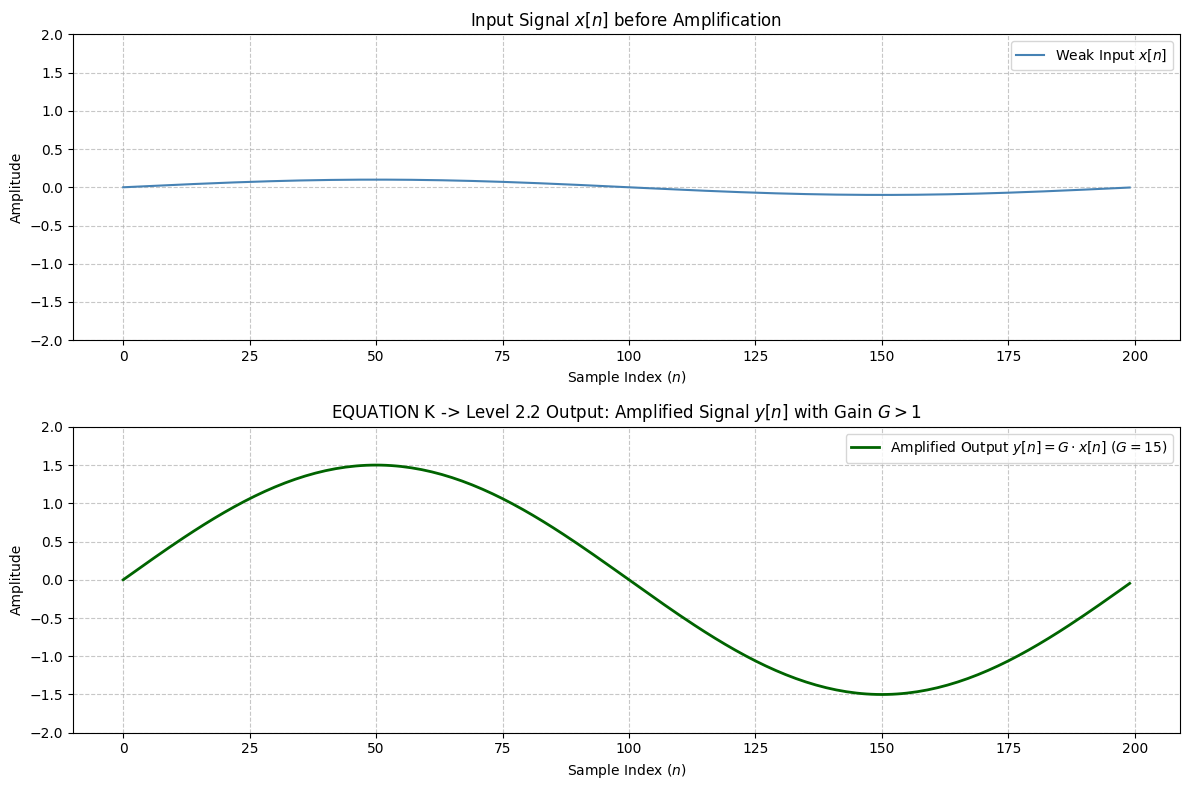

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Input Signal: Weak Micro-Signal x[n]
# ------------------------------------------------------------------------------
fs = 1000                          # Sampling rate (Hz)
N = 200                            # Total number of discrete samples
n = np.arange(N)                   # Discrete sample indices [0, 1, 2, ..., N-1]
t = n / fs                         # Time vector (seconds)

# Weak input signal x[n] with low amplitude (e.g., small sensor or mic output)
x = 0.1 * np.sin(2 * np.pi * 5 * t)

# ------------------------------------------------------------------------------
# 2. Implement Equation K: Discrete-Time Amplification
#    Equation K: y[n] = G * x[n]
# ------------------------------------------------------------------------------
G = 15.0                           # Gain coefficient (G > 1)

# Direct implementation of Equation K
y = G * x                          # Scales each sample x[n] by constant G

# ------------------------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Subplot 1: Weak Input Signal x[n]
plt.subplot(2, 1, 1)
plt.plot(n, x, color='steelblue', linewidth=1.5, label=r'Weak Input $x[n]$')
plt.title(r'Input Signal $x[n]$ before Amplification')
plt.xlabel('Sample Index ($n$)')
plt.ylabel('Amplitude')
plt.ylim(-2.0, 2.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: Amplified Output Signal y[n] via Equation K
plt.subplot(2, 1, 2)
plt.plot(n, y, color='darkgreen', linewidth=2, 
         label=r'Amplified Output $y[n] = G \cdot x[n]$ ($G=15$)')
plt.title(r'EQUATION K -> Level 2.2 Output: Amplified Signal $y[n]$ with Gain $G > 1$')
plt.xlabel('Sample Index ($n$)')
plt.ylabel('Amplitude')
plt.ylim(-2.0, 2.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.3 – Attenuation

Attenuation reduces the amplitude of a signal without changing its shape or frequency content.  
It is commonly used to prevent clipping and balance multiple signals.

### Why Do We Need Attenuation?
* Prevent signal clipping
* Reduce loud music behind speech
* Automatic gain control
* Audio fading

---

## Mathematical Equation
An ideal discrete-time attenuator is defined as:

$$y[n] = G \cdot x[n]$$

Where:
* $0 < G < 1$ is the attenuation factor (gain)
* $x[n]$ is the original input signal
* $y[n]$ is the attenuated output signal

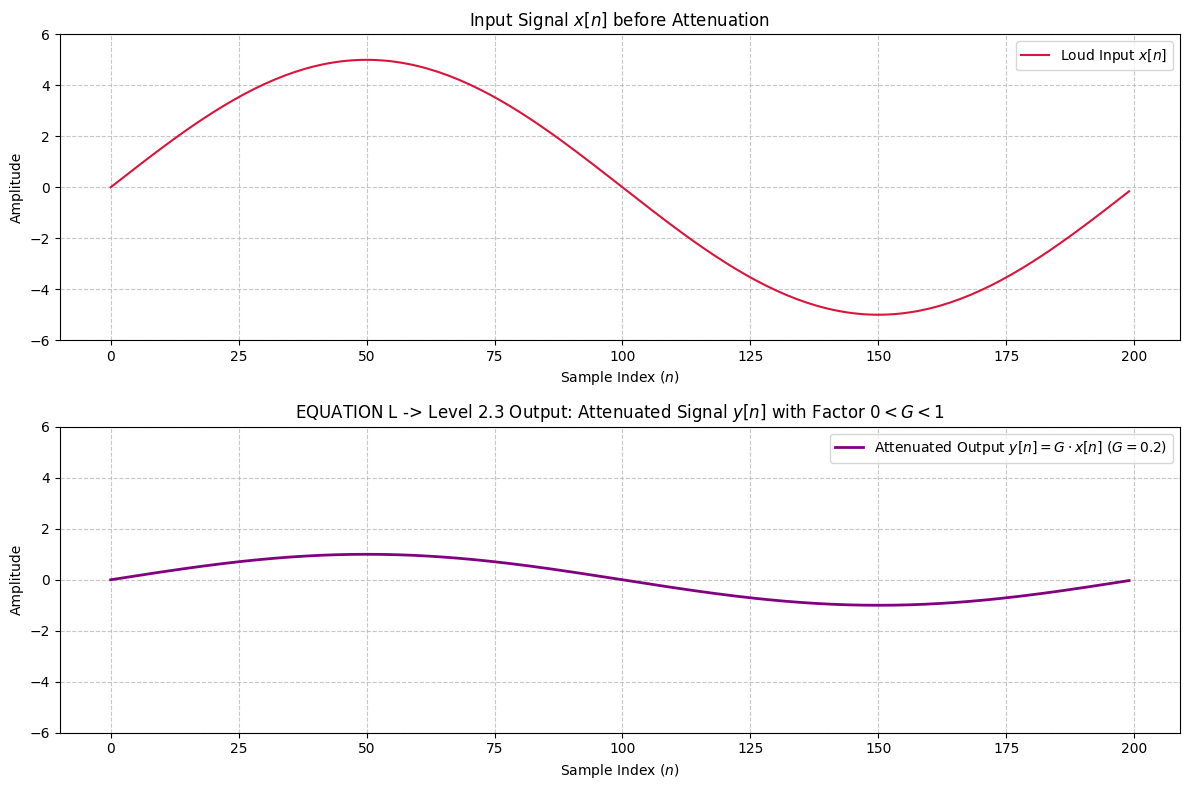

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Input Signal: Overly Loud Input Signal x[n]
# ------------------------------------------------------------------------------
fs = 1000                          # Sampling rate (Hz)
N = 200                            # Total number of discrete samples
n = np.arange(N)                   # Discrete sample indices [0, 1, 2, ..., N-1]
t = n / fs                         # Time vector (seconds)

# High-amplitude input signal x[n] (e.g., loud audio signal prone to clipping)
x = 5.0 * np.sin(2 * np.pi * 5 * t)

# ------------------------------------------------------------------------------
# 2. Implement Equation L: Discrete-Time Attenuation
#    Equation L: y[n] = G * x[n], where 0 < G < 1
# ------------------------------------------------------------------------------
G = 0.2                            # Attenuation factor (0 < G < 1)

# Direct implementation of Equation L
y = G * x                          # Scales down each sample x[n] by factor G

# ------------------------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Subplot 1: High-Amplitude Input Signal x[n]
plt.subplot(2, 1, 1)
plt.plot(n, x, color='crimson', linewidth=1.5, label=r'Loud Input $x[n]$')
plt.title(r'Input Signal $x[n]$ before Attenuation')
plt.xlabel('Sample Index ($n$)')
plt.ylabel('Amplitude')
plt.ylim(-6.0, 6.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: Attenuated Output Signal y[n] via Equation L
plt.subplot(2, 1, 2)
plt.plot(n, y, color='purple', linewidth=2, 
         label=r'Attenuated Output $y[n] = G \cdot x[n]$ ($G=0.2$)')
plt.title(r'EQUATION L -> Level 2.3 Output: Attenuated Signal $y[n]$ with Factor $0 < G < 1$')
plt.xlabel('Sample Index ($n$)')
plt.ylabel('Amplitude')
plt.ylim(-6.0, 6.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.4 – Modulation

Modulation transfers information from a low-frequency signal onto a high-frequency carrier signal.  
Without modulation, radio communication over long distances would not be practical.

### Why Do We Need Modulation?
* Radio broadcasting
* Television
* Wi-Fi
* Bluetooth
* Satellite communication

---

## Mathematical Equation
Amplitude Modulation (AM) in continuous-time is defined as:

$$y(t) = x(t) \cos(2\pi f_c t)$$

Where:
* $x(t)$ is the message (baseband) signal
* $f_c$ is the carrier frequency
* $y(t)$ is the modulated output signal

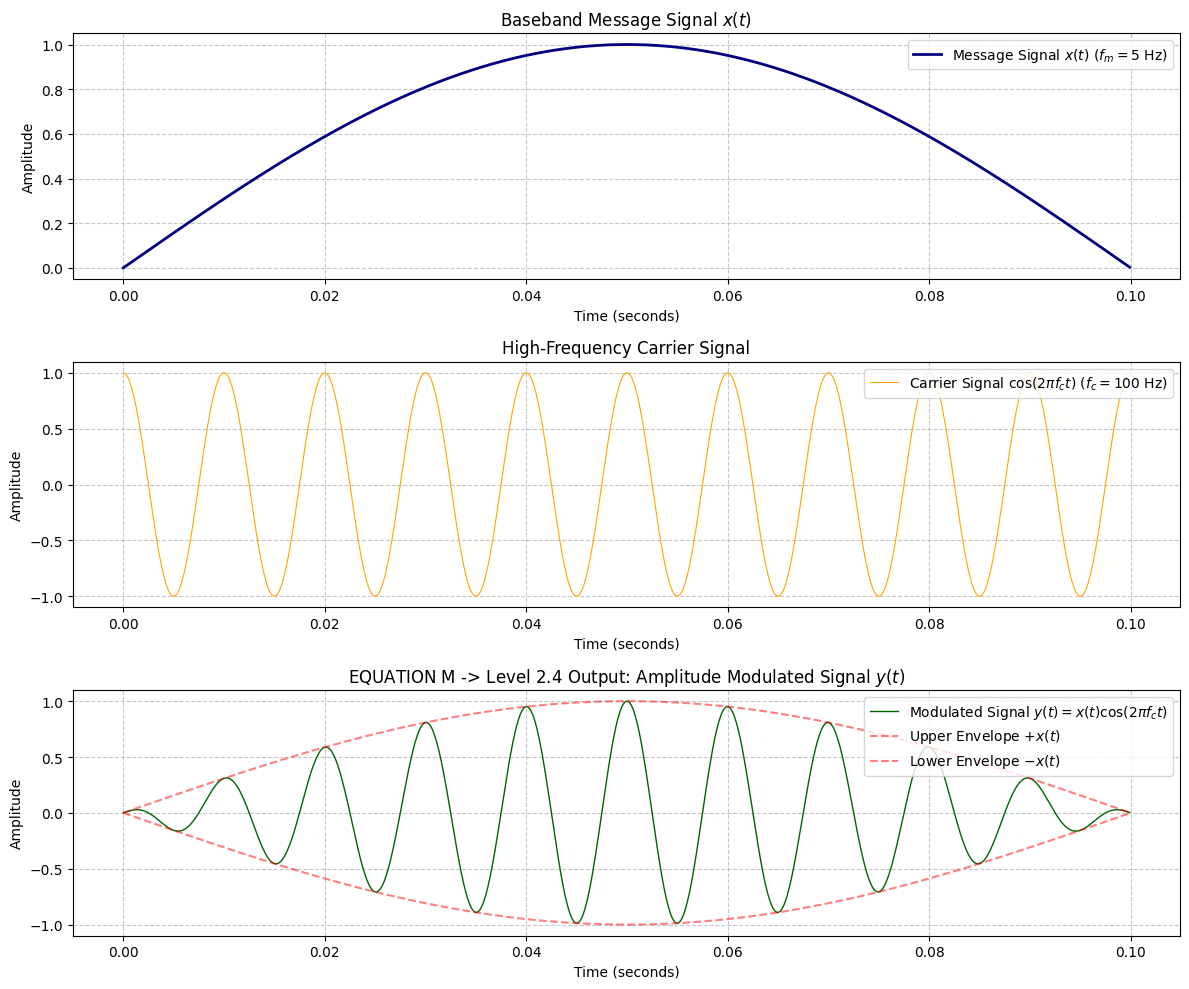

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Signals: Message x(t) and High-Frequency Carrier cos(2*pi*fc*t)
# ------------------------------------------------------------------------------
fs = 10000                         # High sampling rate (Hz) to resolve carrier
N = 1000                           # Total number of samples
n = np.arange(N)                   # Discrete sample indices
t = n / fs                         # Time vector (seconds)

fm = 5                             # Message frequency (5 Hz)
fc = 100                           # Carrier frequency (100 Hz, fc >> fm)

# Low-frequency message (information) signal x(t)
x_t = np.sin(2 * np.pi * fm * t)

# High-frequency carrier signal
carrier = np.cos(2 * np.pi * fc * t)

# ------------------------------------------------------------------------------
# 2. Implement Equation M: Amplitude Modulation (AM)
#    Equation M: y(t) = x(t) * cos(2 * pi * fc * t)
# ------------------------------------------------------------------------------
# Direct element-wise multiplication of message and carrier signals
y_t = x_t * carrier

# ------------------------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 10))

# Subplot 1: Low-Frequency Message Signal x(t)
plt.subplot(3, 1, 1)
plt.plot(t, x_t, color='navy', linewidth=2, label=r'Message Signal $x(t)$ ($f_m = 5\text{ Hz}$)')
plt.title(r'Baseband Message Signal $x(t)$')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: High-Frequency Carrier Signal
plt.subplot(3, 1, 2)
plt.plot(t, carrier, color='orange', linewidth=0.8, label=r'Carrier Signal $\cos(2\pi f_c t)$ ($f_c = 100\text{ Hz}$)')
plt.title(r'High-Frequency Carrier Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 3: Modulated Output Signal y(t) via Equation M
plt.subplot(3, 3, 7) if False else plt.subplot(3, 1, 3)  # Standard 3x1 layout
plt.plot(t, y_t, color='darkgreen', linewidth=1, 
         label=r'Modulated Signal $y(t) = x(t)\cos(2\pi f_c t)$')
plt.plot(t, x_t, 'r--', alpha=0.5, label=r'Upper Envelope $+x(t)$')
plt.plot(t, -x_t, 'r--', alpha=0.5, label=r'Lower Envelope $-x(t)$')
plt.title(r'EQUATION M -> Level 2.4 Output: Amplitude Modulated Signal $y(t)$')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.5 – Demodulation

Demodulation is the reverse of modulation.  
It extracts the original information signal from the received carrier signal.

### Why Do We Need Demodulation?
* Radio receivers
* Television receivers
* Mobile communication
* Wireless networking

---

## Mathematical Equation
Coherent Amplitude Demodulation (AM Detection) is defined as:

$$x(t) = \text{LPF}\left[y(t) \cos(2\pi f_c t)\right]$$

Where:
* $y(t)$ is the received modulated signal
* $f_c$ is the carrier frequency
* $\text{LPF}$ denotes a low-pass filter
* $x(t)$ is the recovered message signal

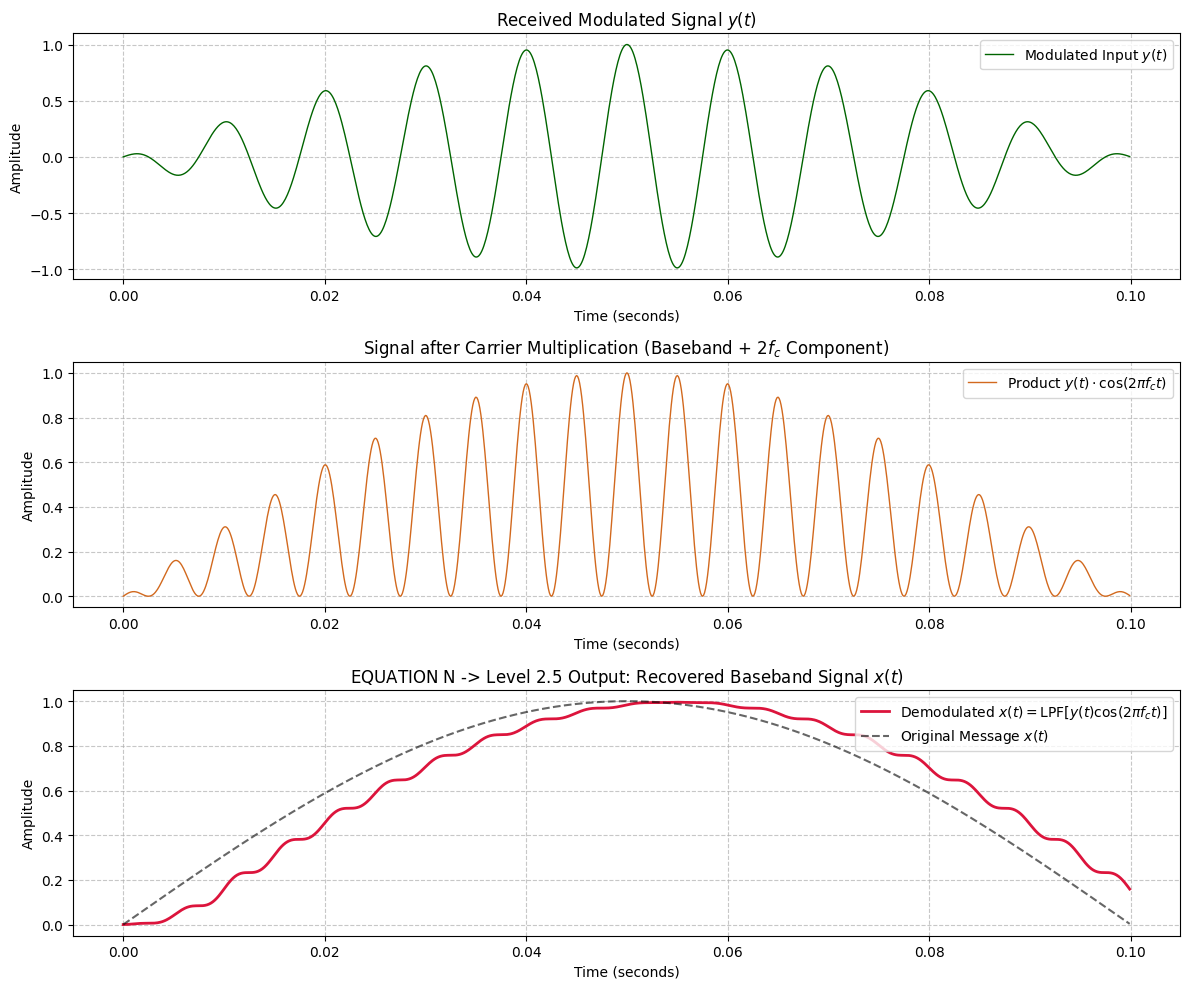

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Input: Generate Modulated Signal y(t)
# ------------------------------------------------------------------------------
fs = 10000                         # Sampling frequency (Hz)
N = 1000                           # Number of samples
n = np.arange(N)                   # Discrete sample indices
t = n / fs                         # Time vector (seconds)

fm = 5                             # Original message frequency (5 Hz)
fc = 100                           # Carrier frequency (100 Hz)

# Baseband message signal (for comparison)
x_original = np.sin(2 * np.pi * fm * t)

# Modulated signal y(t) from Level 2.4
y_t = x_original * np.cos(2 * np.pi * fc * t)

# ------------------------------------------------------------------------------
# 2. Implement Equation N: Coherent AM Demodulation
#    Equation N: x(t) = LPF[ y(t) * cos(2 * pi * fc * t) ]
# ------------------------------------------------------------------------------
# Step A: Multiply received signal y(t) by local carrier cos(2*pi*fc*t)
# Yields: 0.5 * x(t) + 0.5 * x(t) * cos(4 * pi * fc * t)
mixed_signal = y_t * np.cos(2 * np.pi * fc * t)

# Step B: Low-Pass Filtering (LPF) via Moving Average
# Smooths out high-frequency 2*fc (200 Hz) component, leaving 0.5 * x(t)
M = 100                            # LPF Window Size
b_k = np.ones(M) / M               # Moving average impulse response

lpf_output = np.zeros(N)
for n_idx in range(N):
    accumulator = 0.0
    for k in range(M):
        if (n_idx - k) >= 0:
            accumulator += b_k[k] * mixed_signal[n_idx - k]
    lpf_output[n_idx] = accumulator

# Step C: Scale by 2 to compensate for the 1/2 factor from trigonometric identity
x_recovered = 2.0 * lpf_output

# ------------------------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 10))

# Subplot 1: Received Modulated Signal y(t)
plt.subplot(3, 1, 1)
plt.plot(t, y_t, color='darkgreen', linewidth=1, label=r'Modulated Input $y(t)$')
plt.title(r'Received Modulated Signal $y(t)$')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: Product Signal y(t) * cos(2*pi*fc*t)
plt.subplot(3, 1, 2)
plt.plot(t, mixed_signal, color='chocolate', linewidth=1, 
         label=r'Product $y(t) \cdot \cos(2\pi f_c t)$')
plt.title(r'Signal after Carrier Multiplication (Baseband + $2f_c$ Component)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 3: Recovered Message Signal x(t) via LPF
plt.subplot(3, 1, 3)
plt.plot(t, x_recovered, color='crimson', linewidth=2, 
         label=r'Demodulated $x(t) = \text{LPF}[y(t)\cos(2\pi f_c t)]$')
plt.plot(t, x_original, 'k--', alpha=0.6, label=r'Original Message $x(t)$')
plt.title(r'EQUATION N -> Level 2.5 Output: Recovered Baseband Signal $x(t)$')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.6 – Convolution

Convolution describes how a system modifies an input signal.  
Almost every Linear Time-Invariant (LTI) system is mathematically described by convolution.

### Why Do We Need Convolution?
* Digital filters
* Echo generation
* Room acoustics
* Image blurring
* System response

---

## Mathematical Equation
The discrete-time convolution sum is defined as:

$$y[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k]$$

Where:
* $x[n]$ is the input signal
* $h[n]$ is the system impulse response
* $y[n]$ is the output signal

# Level 2.7 – Correlation

Correlation measures the similarity between two signals.  
Unlike convolution, correlation does not model a system; instead, it determines how closely two signals match.

### Why Do We Need Correlation?
* Pattern recognition
* Template matching
* Echo detection
* Synchronization

---

## Mathematical Equation
The cross-correlation sequence between two discrete-time signals is defined as:

$$R_{xy}[m] = \sum_{n=-\infty}^{\infty} x[n] y[n+m]$$

Where:
* $x[n]$ is the reference signal
* $y[n]$ is the target signal
* $m$ is the time shift (lag) parameter
* $R_{xy}[m]$ is the resulting correlation score at lag $m$

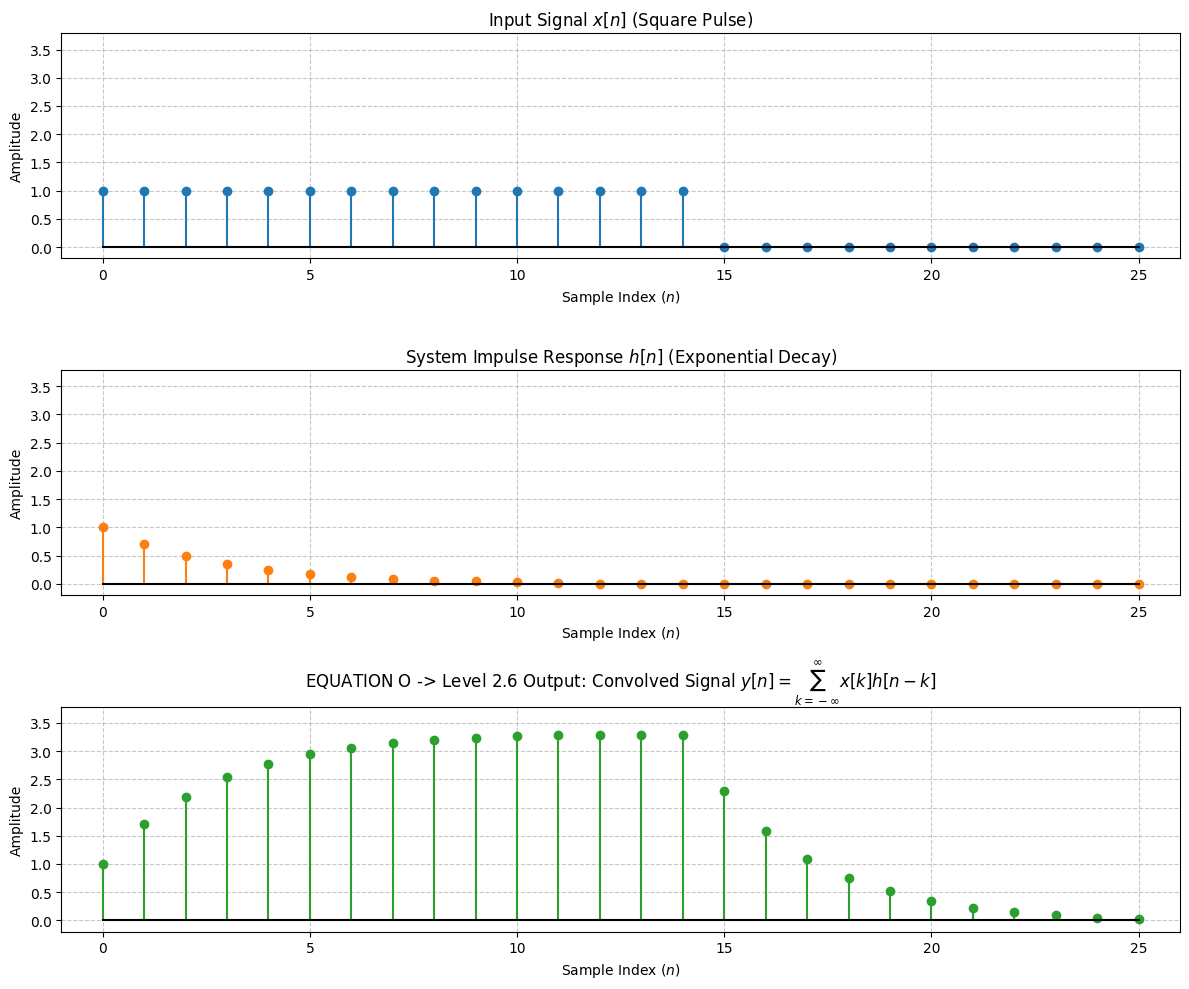

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Input Signal x[n] and System Impulse Response h[n]
# ------------------------------------------------------------------------------
# Input Signal: Short square pulse x[n]
Nx = 15
x = np.ones(Nx)                   # Pulse of amplitude 1 and length 15

# Impulse Response: Exponentially decaying system response h[n]
Nh = 12
k_indices = np.arange(Nh)
h = 0.7 ** k_indices              # Decay factor 0.7

# ------------------------------------------------------------------------------
# 2. Implement Equation O: Discrete-Time Convolution Sum
#    Equation O: y[n] = \sum_{k=-\infty}^{\infty} x[k] * h[n-k]
# ------------------------------------------------------------------------------
Ny = Nx + Nh - 1                  # Output length (26 samples)
y = np.zeros(Ny)

# Explicit implementation of discrete convolution sum
for n in range(Ny):
    accumulator = 0.0
    for k in range(Nx):
        if 0 <= (n - k) < Nh:
            accumulator += x[k] * h[n - k]
    y[n] = accumulator

# Zero-padded versions for uniform array sizing across plots
x_padded = np.pad(x, (0, Ny - Nx))
h_padded = np.pad(h, (0, Ny - Nh))
n_axis = np.arange(Ny)            # Uniform axis: 0 to 25

# Shared axis limits across all plots
xlim_bounds = (-1, Ny)
ylim_bounds = (-0.2, np.max(y) + 0.5)

# ------------------------------------------------------------------------------
# 3. Visualization (Uniform X & Y Scales)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Subplot 1: Input Signal x[n]
axes[0].stem(n_axis, x_padded, linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[0].set_title(r'Input Signal $x[n]$ (Square Pulse)')
axes[0].set_xlabel('Sample Index ($n$)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim(xlim_bounds)
axes[0].set_ylim(ylim_bounds)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Impulse Response h[n]
axes[1].stem(n_axis, h_padded, linefmt='C1-', markerfmt='C1o', basefmt='k-')
axes[1].set_title(r'System Impulse Response $h[n]$ (Exponential Decay)')
axes[1].set_xlabel('Sample Index ($n$)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlim(xlim_bounds)
axes[1].set_ylim(ylim_bounds)
axes[1].grid(True, linestyle='--', alpha=0.7)

# Subplot 3: Convolved Output Signal y[n] via Equation O
axes[2].stem(n_axis, y, linefmt='C2-', markerfmt='C2o', basefmt='k-')
axes[2].set_title(r'EQUATION O -> Level 2.6 Output: Convolved Signal $y[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k]$')
axes[2].set_xlabel('Sample Index ($n$)')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlim(xlim_bounds)
axes[2].set_ylim(ylim_bounds)
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Level 2.8 – Sampling

Sampling converts a continuous-time signal into a discrete-time signal by measuring its amplitude at regular intervals.

### Why Do We Need Sampling?
* Convert analog audio to digital
* Digital communication
* Computer processing

---

## Mathematical Equation
Ideal discrete-time sampling is defined as:

$$x[n] = x(n T_s)$$

Where:
* $T_s$ is the sampling interval
* $f_s = \frac{1}{T_s}$ is the sampling frequency (rate)
* $x(t)$ is the continuous-time analog signal
* $x[n]$ is the resulting discrete-time sequence

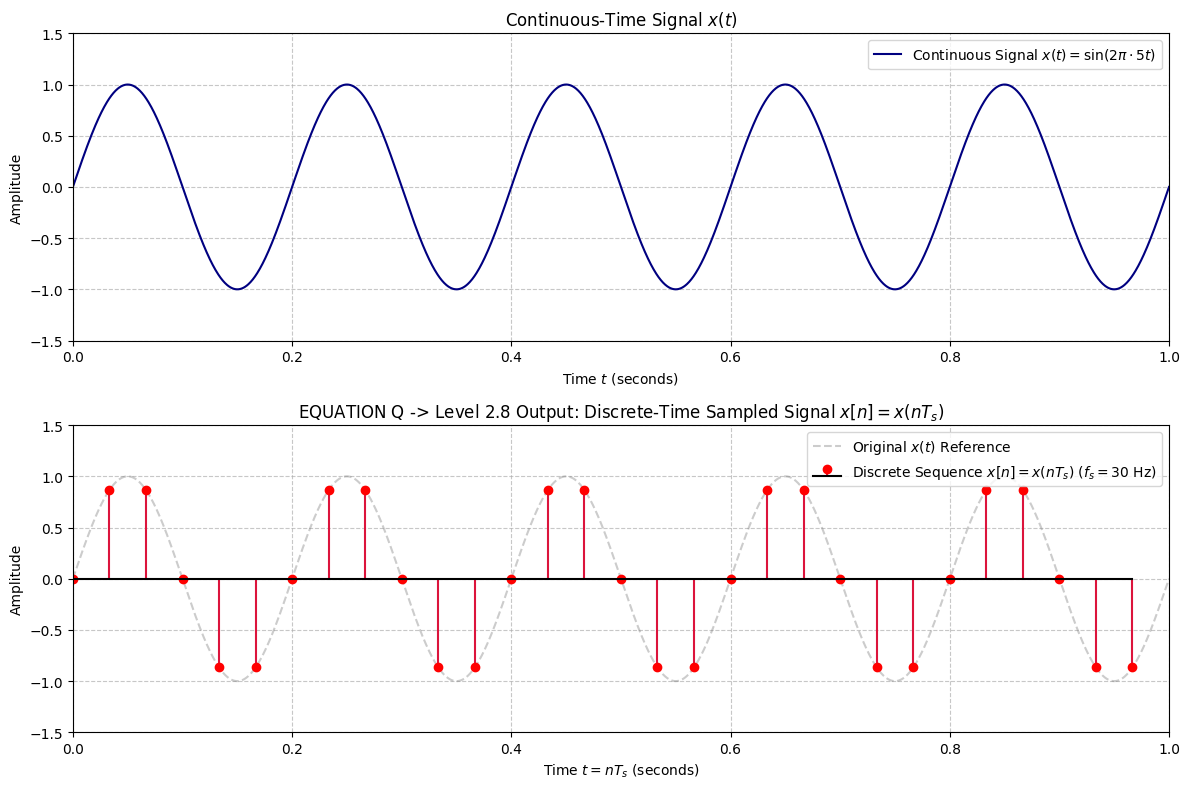

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Continuous-Time Signal Simulation: x(t)
# ------------------------------------------------------------------------------
f_signal = 5.0                     # Analog signal frequency (5 Hz)
t_duration = 1.0                   # Total duration (1 second)

# High-resolution time vector simulating continuous-time domain x(t)
t_continuous = np.linspace(0, t_duration, 2000)
x_continuous = np.sin(2 * np.pi * f_signal * t_continuous)

# ------------------------------------------------------------------------------
# 2. Implement Equation Q: Discrete-Time Sampling x[n] = x(n * Ts)
#    Equation Q: x[n] = x(n * Ts), where Ts = 1 / fs
# ------------------------------------------------------------------------------
fs = 30.0                          # Sampling frequency (30 Hz, satisfies fs > 2*f_signal)
Ts = 1.0 / fs                      # Sampling interval (seconds)

# Discrete sample time indices n = [0, 1, 2, ..., N-1]
n = np.arange(0, int(t_duration * fs))
t_samples = n * Ts                 # Discrete sample times t = n * Ts

# Sample the continuous signal at discrete points n * Ts
x_n = np.sin(2 * np.pi * f_signal * t_samples)

# ------------------------------------------------------------------------------
# 3. Visualization (Uniform Time & Amplitude Scales)
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Shared limits for direct comparison
xlim_bounds = (0, t_duration)
ylim_bounds = (-1.5, 1.5)

# Subplot 1: Continuous Analog Signal x(t)
plt.subplot(2, 1, 1)
plt.plot(t_continuous, x_continuous, color='navy', linewidth=1.5, 
         label=r'Continuous Signal $x(t) = \sin(2\pi \cdot 5t)$')
plt.title(r'Continuous-Time Signal $x(t)$')
plt.xlabel('Time $t$ (seconds)')
plt.ylabel('Amplitude')
plt.xlim(xlim_bounds)
plt.ylim(ylim_bounds)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: Discrete-Time Sampled Sequence x[n] via Equation Q
plt.subplot(2, 1, 2)
# Show underlying continuous waveform as a faint reference
plt.plot(t_continuous, x_continuous, color='gray', linestyle='--', alpha=0.4, 
         label=r'Original $x(t)$ Reference')
# Plot sampled discrete points
plt.stem(t_samples, x_n, linefmt='crimson', markerfmt='ro', basefmt='k-', 
         label=r'Discrete Sequence $x[n] = x(n T_s)$ ($f_s = 30\text{ Hz}$)')
plt.title(r'EQUATION Q -> Level 2.8 Output: Discrete-Time Sampled Signal $x[n] = x(n T_s)$')
plt.xlabel('Time $t = n T_s$ (seconds)')
plt.ylabel('Amplitude')
plt.xlim(xlim_bounds)
plt.ylim(ylim_bounds)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.9 – Quantization


Quantization converts continuous amplitude values into a finite number of discrete levels.

### Why Do We Need Quantization?
* Digital audio
* Image processing
* Analog-to-Digital Converters (ADC)

---

## Mathematical Equation
Uniform discrete-time quantization is defined as:

$$x_q[n] = Q(x[n])$$

Where:
* $x[n]$ is the continuous-amplitude discrete-time sample
* $Q(\cdot)$ is the quantization mapping function
* $x_q[n]$ is the quantized discrete-amplitude output sample

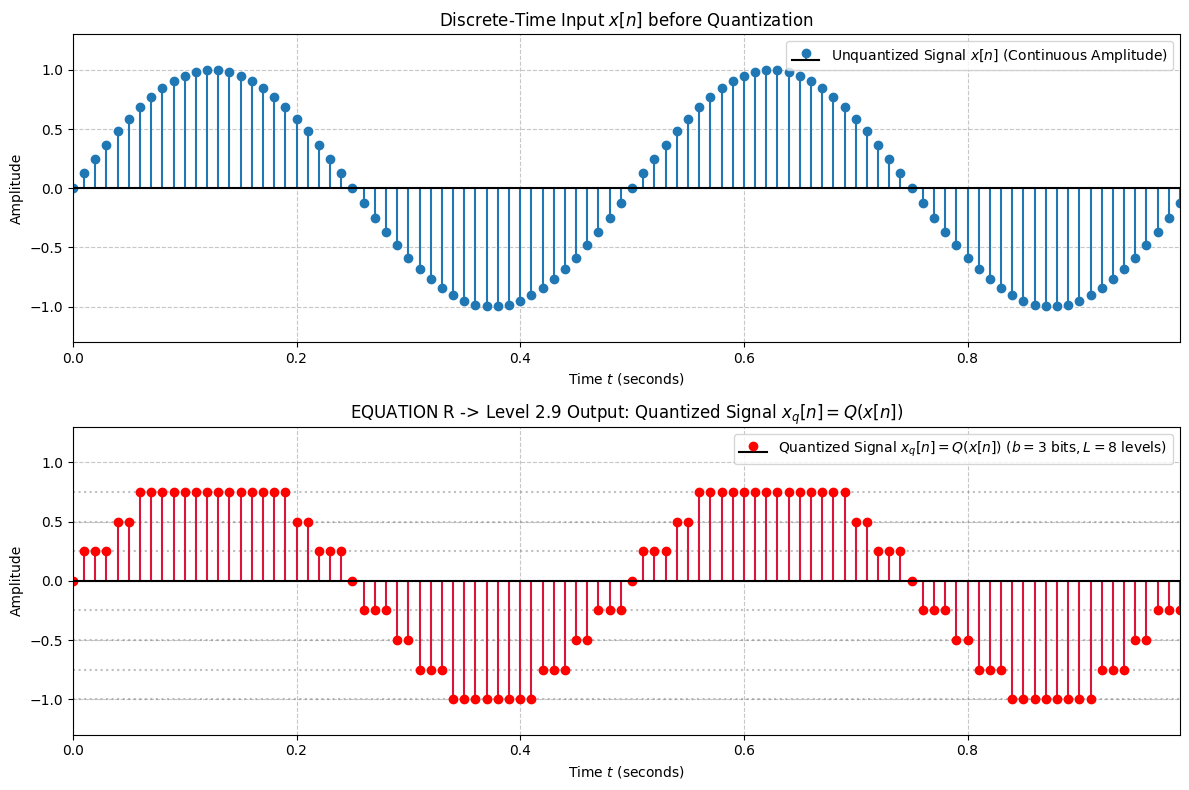

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Discrete-Time Continuous-Amplitude Signal x[n]
# ------------------------------------------------------------------------------
fs = 100                           # Sampling rate (Hz)
N = 100                            # Total number of discrete samples
n = np.arange(N)                   # Discrete sample indices
t = n / fs                         # Discrete time vector (seconds)

# Continuous-amplitude input signal x[n] (range -1.0 to +1.0)
x = np.sin(2 * np.pi * 2 * t)

# ------------------------------------------------------------------------------
# 2. Implement Equation R: Uniform Discrete-Time Quantization
#    Equation R: x_q[n] = Q(x[n])
# ------------------------------------------------------------------------------
b = 3                              # Quantization resolution in bits (2^3 = 8 levels)
L = 2**b                           # Total number of quantization levels (8)

x_min, x_max = -1.0, 1.0           # Full dynamic range
delta = (x_max - x_min) / L        # Step size (resolution between adjacent levels)

# Quantization function Q(x[n]):
# 1. Scale and shift continuous amplitude to level index domain [0, L-1]
indices = np.round((x - x_min) / delta)

# 2. Clip index values to ensure they remain within valid [0, L-1] range
indices = np.clip(indices, 0, L - 1)

# 3. Map discrete indices back to physical amplitude levels
x_q = x_min + indices * delta

# Discrete quantization decision levels array for visualization
quant_levels = x_min + np.arange(L) * delta

# ------------------------------------------------------------------------------
# 3. Visualization (Uniform X & Y Scales)
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

xlim_bounds = (0, t[-1])
ylim_bounds = (-1.3, 1.3)

# Subplot 1: Unquantized Discrete-Time Signal x[n]
plt.subplot(2, 1, 1)
plt.stem(t, x, linefmt='C0-', markerfmt='C0o', basefmt='k-', 
         label=r'Unquantized Signal $x[n]$ (Continuous Amplitude)')
plt.title(r'Discrete-Time Input $x[n]$ before Quantization')
plt.xlabel('Time $t$ (seconds)')
plt.ylabel('Amplitude')
plt.xlim(xlim_bounds)
plt.ylim(ylim_bounds)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: Quantized Discrete-Time Signal x_q[n] via Equation R
plt.subplot(2, 1, 2)
# Draw horizontal dashed lines for the discrete quantization levels Q(·)
for lvl in quant_levels:
    plt.axhline(lvl, color='gray', linestyle=':', alpha=0.5)

plt.stem(t, x_q, linefmt='crimson', markerfmt='ro', basefmt='k-', 
         label=r'Quantized Signal $x_q[n] = Q(x[n])$ ($b=3\text{ bits}, L=8\text{ levels}$)')
plt.title(r'EQUATION R -> Level 2.9 Output: Quantized Signal $x_q[n] = Q(x[n])$')
plt.xlabel('Time $t$ (seconds)')
plt.ylabel('Amplitude')
plt.xlim(xlim_bounds)
plt.ylim(ylim_bounds)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.10 – Transformation

Transformation changes the mathematical representation of a signal without changing the information it contains.  
The most common transformation is converting a signal from the time domain to the frequency domain.

### Why Do We Need Transformation?
* Frequency analysis
* Filter design
* Spectrum visualization
* Compression
* Feature extraction

---

## Mathematical Equation EQUATION S
The Discrete Fourier Transform (DFT) is defined as: 

$$X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi k n / N}$$

Where:
* $x[n]$ is the discrete-time input sequence of length $N$
* $X[k]$ is the discrete-frequency complex output component at index $k$
* $N$ is the total number of samples (transform size)
* $j = \sqrt{-1}$ is the imaginary unit

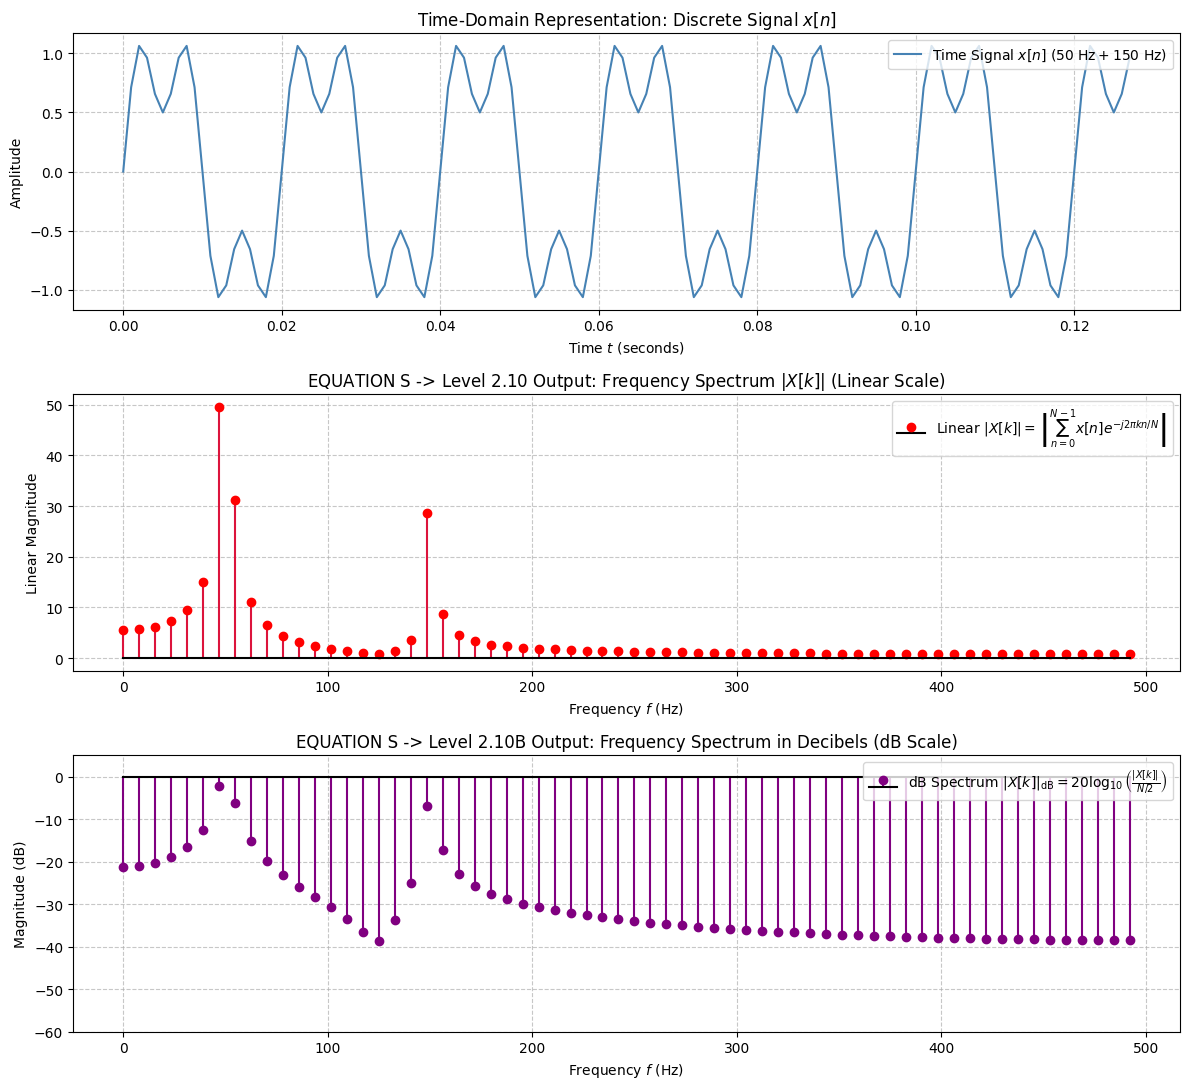

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Setup Discrete-Time Input Signal x[n] (Time Domain)
# ------------------------------------------------------------------------------
fs = 1000                          # Sampling rate (Hz)
N = 128                            # Number of samples (DFT length)
n = np.arange(N)                   # Time sample indices [0, 1, ..., N-1]
t = n / fs                         # Discrete time vector (seconds)

# Mixture of two sine waves: 50 Hz (amplitude 1.0) and 150 Hz (amplitude 0.5)
f1, f2 = 50.0, 150.0
x = 1.0 * np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

# ------------------------------------------------------------------------------
# 2. Implement Equation S: Discrete Fourier Transform (DFT)
#    Equation S: X[k] = \sum_{n=0}^{N-1} x[n] * e^(-j * 2 * pi * k * n / N)
# ------------------------------------------------------------------------------
X = np.zeros(N, dtype=complex)     # Array to store complex DFT coefficients

# Direct calculation of DFT via nested loops
for k in range(N):
    accumulator = 0.0 + 0.0j
    for n_idx in range(N):
        angle = -2.0 * np.pi * k * n_idx / N
        complex_exp = np.exp(1j * angle)
        accumulator += x[n_idx] * complex_exp
    X[k] = accumulator

# Step A: Linear Magnitude Spectrum
magnitude_X = np.abs(X)

# Step B: Decibel (dB) Conversion Spectrum
# Normalized magnitude: |X[k]| / (N / 2)
magnitude_normalized = magnitude_X / (N / 2.0)
# Add small epsilon (1e-12) to avoid log10(0) division errors
magnitude_dB = 20 * np.log10(magnitude_normalized + 1e-12)

# Physical frequency values for single-sided spectrum (0 to fs/2)
half_N = N // 2
freqs = np.arange(half_N) * (fs / N)

# ------------------------------------------------------------------------------
# 3. Visualization: Time Domain, Linear Magnitude, and dB Magnitude
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 11))

# Subplot 1: Time-Domain Input Signal x[n]
plt.subplot(3, 1, 1)
plt.plot(t, x, color='steelblue', linewidth=1.5, 
         label=r'Time Signal $x[n]$ ($50\text{ Hz} + 150\text{ Hz}$)')
plt.title(r'Time-Domain Representation: Discrete Signal $x[n]$')
plt.xlabel('Time $t$ (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 2: Linear Frequency-Domain Spectrum |X[k]|
plt.subplot(3, 1, 2)
plt.stem(freqs, magnitude_X[:half_N], linefmt='crimson', markerfmt='ro', basefmt='k-', 
         label=r'Linear $|X[k]| = \left|\sum_{n=0}^{N-1} x[n] e^{-j 2\pi k n / N}\right|$')
plt.title(r'EQUATION S -> Level 2.10 Output: Frequency Spectrum $|X[k]|$ (Linear Scale)')
plt.xlabel('Frequency $f$ (Hz)')
plt.ylabel('Linear Magnitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Subplot 3: Decibel (dB) Frequency-Domain Spectrum
plt.subplot(3, 1, 3)
plt.stem(freqs, magnitude_dB[:half_N], linefmt='purple', markerfmt='purple', basefmt='k-', 
         label=r'dB Spectrum $|X[k]|_{\text{dB}} = 20 \log_{10}\left(\frac{|X[k]|}{N/2}\right)$')
plt.title(r'EQUATION S -> Level 2.10B Output: Frequency Spectrum in Decibels (dB Scale)')
plt.xlabel('Frequency $f$ (Hz)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-60, 5)                  # Display down to -60 dB floor
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Level 2.10 – Transformation: Time vs. Frequency Domain

The waveform observed in the time domain is a **composite signal** formed by adding multiple individual frequency components together.

<Image src="td_vs_fd.png" alt="Decomposition of a time-domain signal into its frequency components via Fourier Transform" caption="Fourier Transform: Unmixing a signal into its frequency components" />

---

## Why Multiple Frequencies Exist in a Single Waveform

When signals combine in the time domain, their amplitudes add point-by-point at every instant $t$:

$$x[n] = x_1[n] + x_2[n] = \underbrace{1.0 \cdot \sin(2\pi \cdot 50 \cdot t)}_{\text{Low Frequency Component (50 Hz)}} + \underbrace{0.5 \cdot \sin(2\pi \cdot 150 \cdot t)}_{\text{High Frequency Component (150 Hz)}}$$

1. **Time Domain view:** Shows the net resulting waveform. The $50\text{ Hz}$ sine wave forms the main low-frequency shape, while the $150\text{ Hz}$ wave appears as high-frequency ripples riding on top.
2. **Frequency Domain view:** The **Discrete Fourier Transform (DFT)** acts like a prism. It decomposes the combined time-domain signal back into its fundamental sinusoids, showing distinct spectral peaks at **$50\text{ Hz}$** and **$150\text{ Hz}$**.

